install libraries 

In [1]:
import subprocess, sys

packages = [
    'osmnx', 'geopandas', 'pandas', 'numpy',
    'matplotlib', 'scikit-learn', 'xgboost',
    'shap', 'scipy', 'networkx', 'contextily'
]

for p in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', p, '-q'])

print("All libraries installed and ready.")

All libraries installed and ready.


import everything

In [2]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from scipy.stats import entropy as shannon_entropy

print("All imports successful.")
print(f"OSMnx version: {ox.__version__}")

All imports successful.
OSMnx version: 2.1.0


load saved data

In [3]:
# Load saved data — no need to download from OSM again
edges = gpd.read_file("/home/jovyan/work/data/london_streets.gpkg")
buildings = gpd.read_file("/home/jovyan/work/data/london_buildings.gpkg")
pois = gpd.read_file("/home/jovyan/work/data/london_pois.gpkg")

print(f"Streets loaded: {len(edges)}")
print(f"Buildings loaded: {len(buildings)}")
print(f"POIs loaded: {len(pois)}")
print("All data loaded from saved files.")

Streets loaded: 1382
Buildings loaded: 2104
POIs loaded: 3388
All data loaded from saved files.


project to British National Grid

In [4]:
# Convert from latitude/longitude to metres
# EPSG:27700 = British National Grid — correct for London
edges_proj = edges.to_crs(epsg=27700)
buildings_proj = buildings.to_crs(epsg=27700)
pois_proj = pois.to_crs(epsg=27700)

# Create 50m buffer around each street segment
# This is the zone we measure everything within
edges_buffered = edges_proj.copy()
edges_buffered['geometry'] = edges_proj.geometry.buffer(50)

print(f"Projected to British National Grid")
print(f"Average segment length: {edges_proj.geometry.length.mean():.1f}m")
print(f"Buffer created: 50m around each segment")
print(f"CRS check — all match: {edges_proj.crs == buildings_proj.crs == pois_proj.crs}")

Projected to British National Grid
Average segment length: 59.7m
Buffer created: 50m around each segment
CRS check — all match: True


calculate basic features

In [5]:
# === FEATURE 1: Segment length ===
edges_proj['length_m'] = edges_proj.geometry.length

# === FEATURE 2: Building count within 50m ===
joined_b = gpd.sjoin(edges_buffered[['geometry']], 
                     buildings_proj[['geometry']], 
                     how='left', predicate='intersects')
edges_proj['building_count_50m'] = joined_b.groupby(
    joined_b.index).size().reindex(edges_proj.index, fill_value=0)

# === FEATURE 3: Average building area within 50m ===
buildings_proj['area'] = buildings_proj.geometry.area
joined_ba = gpd.sjoin(edges_buffered[['geometry']], 
                      buildings_proj[['geometry','area']], 
                      how='left', predicate='intersects')
edges_proj['avg_building_area'] = joined_ba.groupby(
    joined_ba.index)['area'].mean().reindex(edges_proj.index, fill_value=0)

# === FEATURE 4: POI count within 50m ===
joined_p = gpd.sjoin(edges_buffered[['geometry']], 
                     pois_proj[['geometry']], 
                     how='left', predicate='intersects')
edges_proj['poi_count_50m'] = joined_p.groupby(
    joined_p.index).size().reindex(edges_proj.index, fill_value=0)

# === FEATURE 5: Highway rank ===
def clean_highway(val):
    if isinstance(val, list):
        return val[0]
    return val

highway_map = {
    'trunk': 6, 'primary': 5, 'primary_link': 5,
    'secondary': 4, 'secondary_link': 4,
    'tertiary': 3, 'tertiary_link': 3,
    'residential': 2, 'living_street': 2, 'unclassified': 1
}
edges_proj['highway_clean'] = edges_proj['highway'].apply(clean_highway)
edges_proj['highway_rank'] = edges_proj['highway_clean'].map(
    highway_map).fillna(1)

# === FEATURE 6: Sinuosity ===
def calculate_sinuosity(geom):
    if geom.length == 0:
        return 1.0
    start = geom.coords[0]
    end = geom.coords[-1]
    straight = ((end[0]-start[0])**2 + (end[1]-start[1])**2)**0.5
    if straight == 0:
        return 1.0
    return geom.length / straight

edges_proj['sinuosity'] = edges_proj.geometry.apply(calculate_sinuosity)

print("Basic features calculated.")
print(f"Length — min: {edges_proj['length_m'].min():.1f}m, max: {edges_proj['length_m'].max():.1f}m")
print(f"Buildings within 50m — average: {edges_proj['building_count_50m'].mean():.1f}")
print(f"POI within 50m — average: {edges_proj['poi_count_50m'].mean():.1f}")
print(f"Highway ranks: {sorted(edges_proj['highway_rank'].unique())}")
print(f"Sinuosity — average: {edges_proj['sinuosity'].mean():.3f}, max: {edges_proj['sinuosity'].max():.3f}")

Basic features calculated.
Length — min: 1.1m, max: 447.2m
Buildings within 50m — average: 16.2
POI within 50m — average: 17.9
Highway ranks: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]
Sinuosity — average: 1.042, max: 4.873


POI categories and diversity features

In [6]:
# Define meaningful POI categories
# Following Gehl (2010) human-centred street quality framework
food_drink = ['restaurant','fast_food','cafe','pub','bar']
transport = ['bicycle_parking','bicycle_rental','motorcycle_parking','parking']
finance = ['bank','atm']
civic = ['place_of_worship','doctors','dentist','pharmacy']
street_furniture = ['bench','fountain','clock','telephone','post_box']

def categorise_poi(row):
    amenity = str(row.get('amenity',''))
    shop = str(row.get('shop',''))
    if amenity in food_drink: return 'food_drink'
    elif amenity in transport: return 'transport'
    elif amenity in finance: return 'finance'
    elif amenity in civic: return 'civic'
    elif amenity in street_furniture: return 'street_furniture'
    elif shop not in ['nan','']: return 'retail'
    else: return 'other'

pois_proj['category'] = pois_proj.apply(categorise_poi, axis=1)

# === FEATURE 7: POI diversity (Shannon entropy) ===
joined_cats = gpd.sjoin(edges_buffered[['geometry']], 
                         pois_proj[['geometry','category']], 
                         how='left', predicate='intersects')

def calc_entropy(group):
    counts = group['category'].value_counts()
    return shannon_entropy(counts)

poi_entropy = joined_cats.groupby(joined_cats.index).apply(calc_entropy)
edges_proj['poi_diversity'] = poi_entropy.reindex(
    edges_proj.index, fill_value=0)

# === FEATURE 8: Food and drink count ===
food_pois = pois_proj[pois_proj['category']=='food_drink']
joined_food = gpd.sjoin(edges_buffered[['geometry']], 
                         food_pois[['geometry']], 
                         how='left', predicate='intersects')
edges_proj['food_drink_count'] = joined_food.groupby(
    joined_food.index).size().reindex(edges_proj.index, fill_value=0)

# === FEATURE 9: Street furniture count ===
furn_pois = pois_proj[pois_proj['category']=='street_furniture']
joined_furn = gpd.sjoin(edges_buffered[['geometry']], 
                         furn_pois[['geometry']], 
                         how='left', predicate='intersects')
edges_proj['street_furniture_count'] = joined_furn.groupby(
    joined_furn.index).size().reindex(edges_proj.index, fill_value=0)

print("POI features calculated.")
print(f"POI diversity — range: {edges_proj['poi_diversity'].min():.2f} to {edges_proj['poi_diversity'].max():.2f}")
print(f"Food and drink — average: {edges_proj['food_drink_count'].mean():.1f}")
print(f"Street furniture — average: {edges_proj['street_furniture_count'].mean():.1f}")
print(f"POI categories: {pois_proj['category'].value_counts().to_dict()}")

POI features calculated.
POI diversity — range: 0.00 to 1.75
Food and drink — average: 5.6
Street furniture — average: 3.6
POI categories: {'food_drink': 1007, 'retail': 883, 'street_furniture': 723, 'transport': 530, 'civic': 140, 'finance': 105}


network features

In [7]:
# Reload the graph for network calculations
print("Loading street network graph...")
G = ox.graph_from_place("City of London, UK", network_type="drive")

# === FEATURE 10: Average connectivity ===
# How many streets connect at each end of the segment
degree_dict = dict(G.degree())
edges_reset = edges_proj.reset_index()
edges_reset['degree_u'] = edges_reset['u'].map(degree_dict)
edges_reset['degree_v'] = edges_reset['v'].map(degree_dict)
edges_reset['avg_connectivity'] = (edges_reset['degree_u'] + 
                                    edges_reset['degree_v']) / 2
edges_proj = edges_reset.set_index(['u','v','key'])

# === FEATURE 11: Betweenness centrality ===
# How important is this street for movement through the network
# This is the key movement feature TfL framework requires
print("Calculating betweenness centrality — takes about 1 minute...")
edge_centrality = nx.edge_betweenness_centrality(G, normalized=True)

def get_centrality(row):
    k1 = (row['u'], row['v'], row['key'])
    k2 = (row['v'], row['u'], row['key'])
    if k1 in edge_centrality: return edge_centrality[k1]
    elif k2 in edge_centrality: return edge_centrality[k2]
    return 0.0

edges_reset2 = edges_proj.reset_index()
edges_reset2['betweenness'] = edges_reset2.apply(get_centrality, axis=1)
edges_proj = edges_reset2.set_index(['u','v','key'])

print("Network features calculated.")
print(f"Connectivity — average: {edges_proj['avg_connectivity'].mean():.2f}, max: {edges_proj['avg_connectivity'].max():.0f}")
print(f"Betweenness — average: {edges_proj['betweenness'].mean():.4f}, max: {edges_proj['betweenness'].max():.4f}")
print(f"High betweenness streets (top 10%): {(edges_proj['betweenness'] > edges_proj['betweenness'].quantile(0.9)).sum()}")

Loading street network graph...
Calculating betweenness centrality — takes about 1 minute...
Network features calculated.
Connectivity — average: 4.62, max: 8
Betweenness — average: 0.0154, max: 0.1490
High betweenness streets (top 10%): 139


movement and place scores

In [8]:
# Following TfL Street Family framework (Transport for London, 2017)
# Streets are positioned on two axes: Movement and Place

# MOVEMENT features — how important is this street for traffic and getting around
movement_features = [
    'length_m',          # Road scale
    'highway_rank',      # Road classification
    'avg_connectivity',  # Network connections
    'betweenness',       # Through-movement importance
    'sinuosity'          # Straight = movement oriented
]

# PLACE features — how important is this street as a destination
place_features = [
    'poi_count_50m',           # Destination density
    'poi_diversity',           # Mix of uses
    'food_drink_count',        # Street level activity
    'street_furniture_count',  # Pedestrian amenity
    'building_count_50m',      # Built environment density
    'avg_building_area'        # Building scale
]

all_features = movement_features + place_features

# Check all features exist
missing = [f for f in all_features if f not in edges_proj.columns]
if missing:
    print(f"MISSING FEATURES: {missing}")
else:
    print("All 11 features present.")

# Normalise each group separately
scaler_m = StandardScaler()
scaler_p = StandardScaler()

movement_scaled = scaler_m.fit_transform(
    edges_proj[movement_features].fillna(0))
place_scaled = scaler_p.fit_transform(
    edges_proj[place_features].fillna(0))

# Calculate composite scores
edges_proj['movement_score'] = movement_scaled.mean(axis=1)
edges_proj['place_score'] = place_scaled.mean(axis=1)

# Normalise to 0-1 range for interpretability
mm = MinMaxScaler()
scores = mm.fit_transform(
    edges_proj[['movement_score','place_score']])
edges_proj['movement_score_norm'] = scores[:,0]
edges_proj['place_score_norm'] = scores[:,1]

print(f"\nMovement score — average: {edges_proj['movement_score_norm'].mean():.2f}")
print(f"Place score — average: {edges_proj['place_score_norm'].mean():.2f}")
print("\nFeature summary:")
print(edges_proj[all_features].describe().round(2))

All 11 features present.

Movement score — average: 0.22
Place score — average: 0.33

Feature summary:
       length_m  highway_rank  avg_connectivity  betweenness  sinuosity  \
count   1382.00       1382.00           1382.00      1382.00    1382.00   
mean      59.71          2.53              4.62         0.02       1.04   
std       50.99          1.47              1.13         0.02       0.21   
min        1.12          1.00              2.00         0.00       1.00   
25%       25.35          1.00              4.00         0.00       1.00   
50%       47.88          2.00              4.50         0.01       1.00   
75%       78.96          3.00              5.50         0.02       1.01   
max      447.15          6.00              8.00         0.15       4.87   

       poi_count_50m  poi_diversity  food_drink_count  street_furniture_count  \
count        1382.00        1382.00           1382.00                 1382.00   
mean           17.86           1.17              5.58      

normalise and cluster

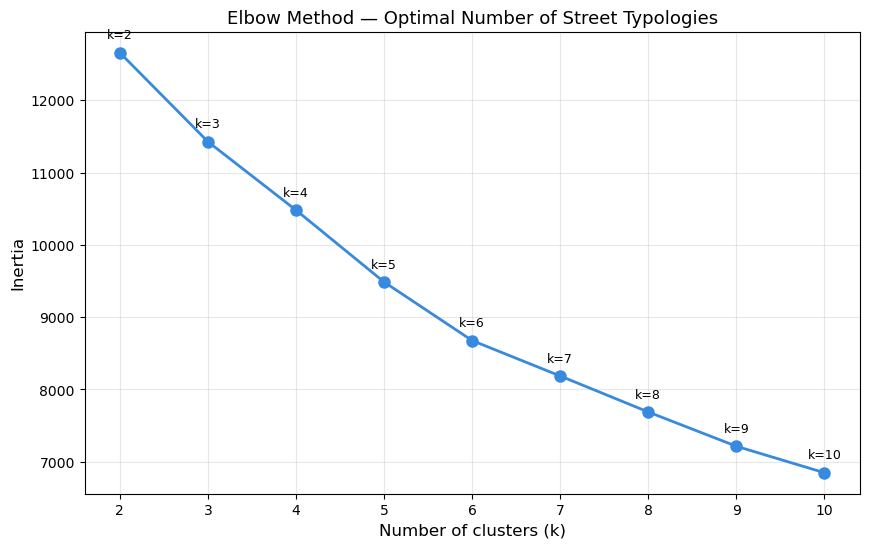

Elbow curve saved.


In [9]:
# Normalise all features together for clustering
scaler = StandardScaler()
X = edges_proj[all_features].fillna(0).values
X_scaled = scaler.fit_transform(X)

# Find optimal number of clusters using elbow method
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Plot elbow curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_range, inertia, 'o-', color='#378ADD', linewidth=2, markersize=8)
ax.set_xlabel('Number of clusters (k)', fontsize=12)
ax.set_ylabel('Inertia', fontsize=12)
ax.set_title('Elbow Method — Optimal Number of Street Typologies', fontsize=13)
ax.grid(True, alpha=0.3)

for k, val in zip(k_range, inertia):
    ax.annotate(f'k={k}', (k, val), 
                textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=9)

plt.savefig("/home/jovyan/work/outputs/elbow_curve_v2.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Elbow curve saved.")

The curve is smoother this time because you have 11 features instead of 5 — more information means more gradual improvement with each cluster added.
Looking at this curve the elbow is at k=5 again. The drop from k=4 to k=5 is noticeable, and from k=5 onwards the line becomes much flatter. Five typologies is still your optimal number and it aligns well with the TfL framework which has a similar number of meaningful street types.

run K-means with 5 clusters

In [10]:
# Run K-means with k=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
edges_proj['cluster'] = kmeans.fit_predict(X_scaled)

# Show cluster sizes
print("Segments per cluster:")
print(edges_proj['cluster'].value_counts().sort_index())

# Show average feature values per cluster
print("\nCluster profiles:")
print(edges_proj.groupby('cluster')[all_features].mean().round(3))

Segments per cluster:
cluster
0    624
1    279
2      9
3    268
4    202
Name: count, dtype: int64

Cluster profiles:
         length_m  highway_rank  avg_connectivity  betweenness  sinuosity  \
cluster                                                                     
0          55.593         1.803             4.758        0.006      1.037   
1          72.271         4.470             4.389        0.042      1.013   
2         117.507         1.333             4.889        0.005      3.268   
3          34.741         2.216             4.175        0.007      1.015   
4          85.603         2.579             5.072        0.018      1.037   

         poi_count_50m  poi_diversity  food_drink_count  \
cluster                                                   
0               15.708          1.257             4.700   
1               18.692          1.269             4.118   
2               21.000          1.331             3.444   
3                6.396          0.758        

5 clusters:
Cluster 0 — 624 streets

Moderate everything. Average length, low highway rank, average POI, average connectivity. This is the everyday background fabric of the City. Low betweenness means not much through traffic. Medium place score.

Name: Local Mixed Street
Cluster 1 — 279 streets

Highest highway rank (4.47 — near primary/secondary), highest betweenness (0.042 — most important for movement), long segments (72m), high street furniture. These are your major roads that carry significant through traffic.

Name: Arterial Movement Corridor
Cluster 2 — 9 streets

Only 9 segments but dramatic sinuosity (3.27 — extremely curved). Longest segments. These are your medieval winding lanes again — found automatically from curvature data alone.

Name: Winding Historic Lane
Cluster 3 — 268 streets

Lowest POI (6.4), lowest food and drink (1.7), lowest diversity (0.76), smallest segments (34m), biggest buildings (2,462 sq metres). Very little street activity, dominated by enormous corporate buildings. Dead frontage institutional streets.

Name: Institutional Dead-Frontage Street
Cluster 4 — 202 streets

By far highest POI (38.4), highest food and drink (15.5), highest building count (30.7), smallest buildings (822 sq metres — lots of small active units). These are your most active, human-centred streets.

Name: Active Commercial High Street

 name clusters and create movement vs place plot

Typology distribution:
typology
Local Mixed Street                    624
Arterial Movement Corridor            279
Institutional Dead-Frontage Street    268
Active Commercial High Street         202
Winding Historic Lane                   9
Name: count, dtype: int64


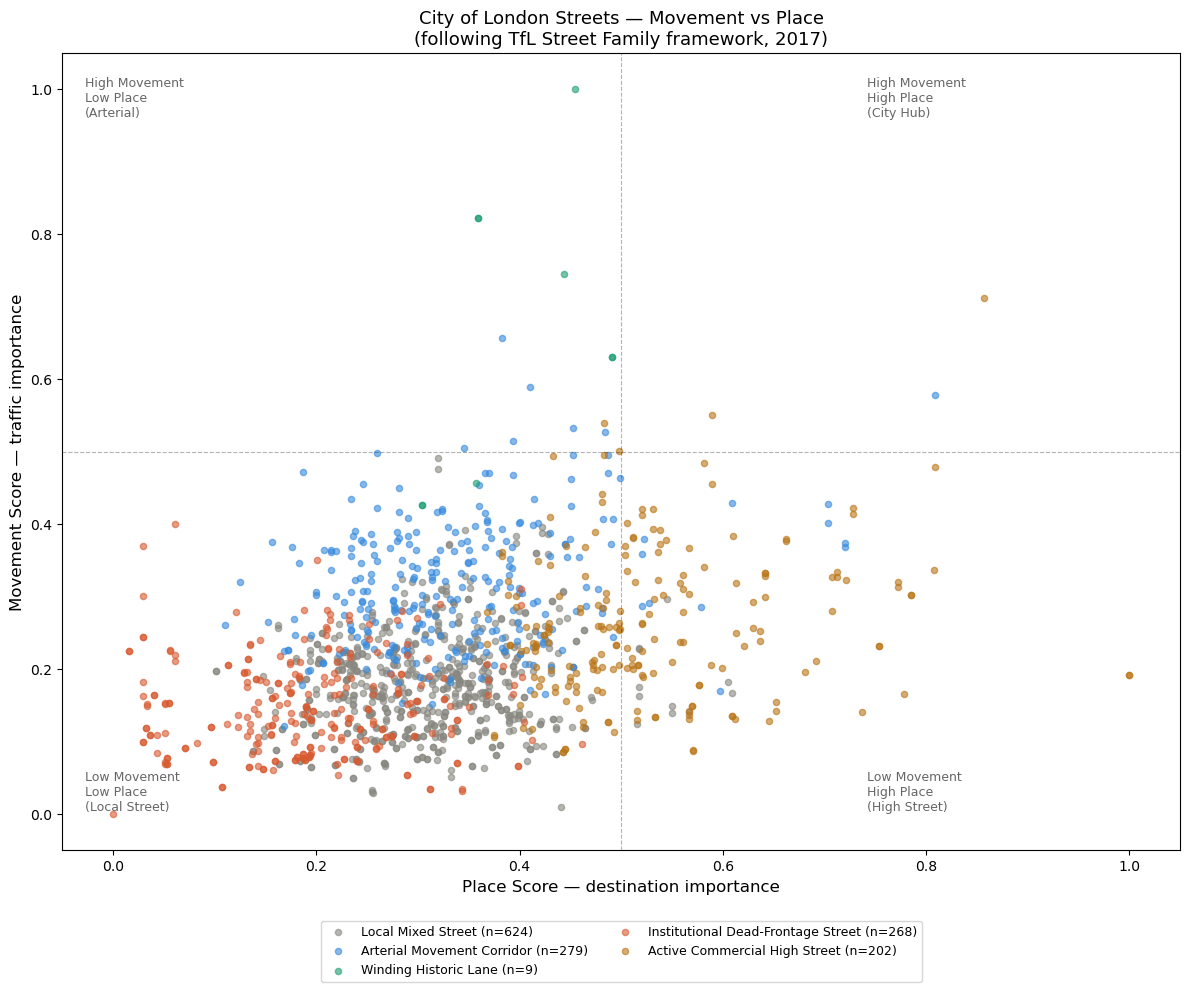

Movement vs Place plot saved.


In [11]:
# Name clusters based on feature profiles
cluster_names = {
    0: 'Local Mixed Street',
    1: 'Arterial Movement Corridor',
    2: 'Winding Historic Lane',
    3: 'Institutional Dead-Frontage Street',
    4: 'Active Commercial High Street'
}

edges_proj['typology'] = edges_proj['cluster'].map(cluster_names)

print("Typology distribution:")
print(edges_proj['typology'].value_counts())

# Colour map
colours = {
    'Local Mixed Street': '#888780',
    'Arterial Movement Corridor': '#378ADD',
    'Winding Historic Lane': '#1D9E75',
    'Institutional Dead-Frontage Street': '#D85A30',
    'Active Commercial High Street': '#BA7517'
}

# Movement vs Place scatter plot
fig, ax = plt.subplots(figsize=(12, 10))

for typology, colour in colours.items():
    mask = edges_proj['typology'] == typology
    ax.scatter(
        edges_proj.loc[mask, 'place_score_norm'],
        edges_proj.loc[mask, 'movement_score_norm'],
        c=colour, alpha=0.6, s=20, label=f'{typology} (n={mask.sum()})'
    )

# Quadrant dividers
ax.axhline(y=0.5, color='black', linewidth=0.8, 
           linestyle='--', alpha=0.3)
ax.axvline(x=0.5, color='black', linewidth=0.8, 
           linestyle='--', alpha=0.3)

# Quadrant labels following TfL framework
ax.text(0.02, 0.97, 'High Movement\nLow Place\n(Arterial)', 
        transform=ax.transAxes, fontsize=9, 
        color='#666666', verticalalignment='top')
ax.text(0.72, 0.97, 'High Movement\nHigh Place\n(City Hub)', 
        transform=ax.transAxes, fontsize=9, 
        color='#666666', verticalalignment='top')
ax.text(0.02, 0.05, 'Low Movement\nLow Place\n(Local Street)', 
        transform=ax.transAxes, fontsize=9, color='#666666')
ax.text(0.72, 0.05, 'Low Movement\nHigh Place\n(High Street)', 
        transform=ax.transAxes, fontsize=9, color='#666666')

ax.set_xlabel('Place Score — destination importance', fontsize=12)
ax.set_ylabel('Movement Score — traffic importance', fontsize=12)
ax.set_title('City of London Streets — Movement vs Place\n(following TfL Street Family framework, 2017)', 
             fontsize=13)
ax.legend(loc='upper center', fontsize=9,
          bbox_to_anchor=(0.5, -0.08), ncol=2)

plt.tight_layout()
plt.savefig("/home/jovyan/work/outputs/movement_place_plot.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Movement vs Place plot saved.")

The movement and place scores are normalised to a scale of 0 to 1. Zero means the lowest scoring street in the dataset on that dimension and 1 means the highest. This makes the scores directly comparable across streets and allows them to be plotted in a two dimensional space that mirrors the TfL movement and place grid. 

two dimensional typology plot following the TfL framework
What this plot is showing:
Every dot is one street segment positioned by its movement score on the Y axis and its place score on the X axis.

Blue dots — Arterial Movement Corridor sit in the upper middle area. High movement, moderate place. Exactly where TfL would put arterial roads.
Gold dots — Active Commercial High Street cluster strongly to the right. Low to moderate movement but very high place score. Exactly where TfL would put high streets — destinations people come to, not roads people drive through.
Orange dots — Institutional Dead-Frontage Street cluster bottom left. Low movement AND low place. These streets score poorly on both axes — exactly what you would expect from streets flanked by blank corporate building walls.
Grey dots — Local Mixed Street spread across the middle-left. Moderate scores on both axes — the everyday background streets of the city.
Green dots — Winding Historic Lane appear as outliers at the top. Their high movement score is driven by their extreme sinuosity and length rather than actual traffic importance. This is an interesting finding worth discussing.

typology map

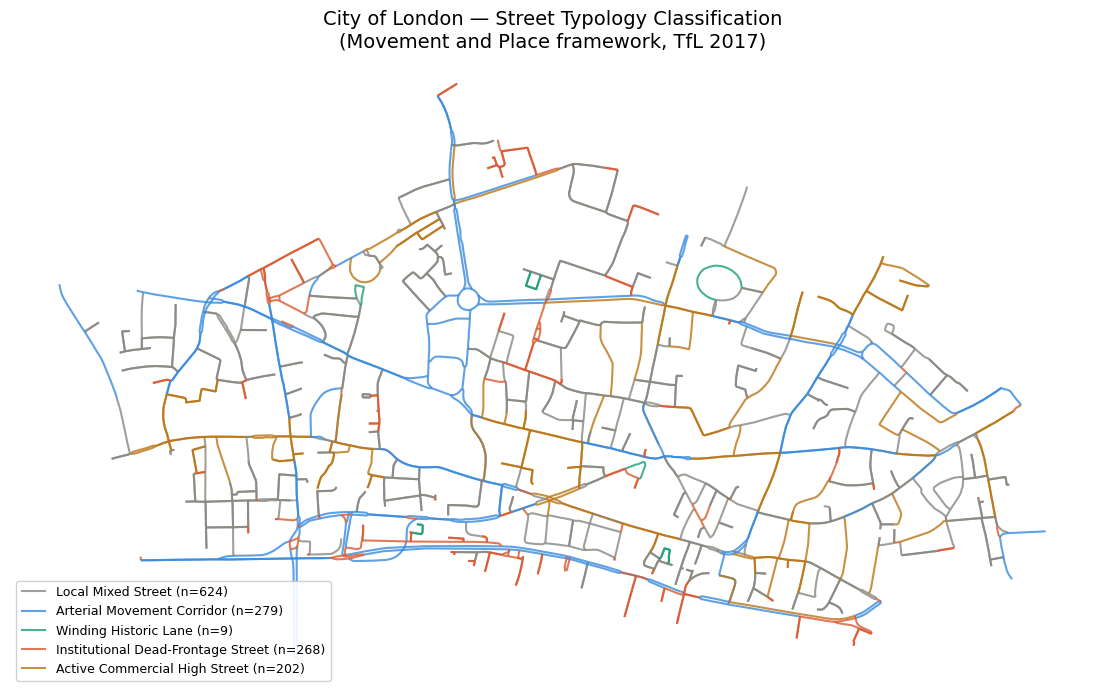

Typology map saved.


In [12]:
# Plot typology map
fig, ax = plt.subplots(figsize=(14, 10))

edges_typed = edges_proj.copy().reset_index()

for typology, colour in colours.items():
    subset = edges_typed[edges_typed['typology'] == typology]
    subset.plot(ax=ax, color=colour, linewidth=1.5,
                label=f'{typology} (n={len(subset)})', 
                alpha=0.8)

ax.set_title("City of London — Street Typology Classification\n(Movement and Place framework, TfL 2017)", 
             fontsize=14)
ax.set_axis_off()
ax.legend(loc='lower left', fontsize=9, framealpha=0.9)

plt.savefig("/home/jovyan/work/outputs/london_typology_final.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Typology map saved.")